# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Global Country Ranking Dataset](https://www.kaggle.com/datasets/ashyou09/global-country-indices-real-database-2000-2026/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/kaggle/input/datasets/ashyou09/global-country-indices-real-database-2000-2026/global_country_rankings_2000_2026.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('global_country_rankings_2000_2026.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Country,Year,Region,Economic_Tier,Happiness_Rank,Global_Hunger_Rank,Human_Development_Rank,GDP_Per_Capita_Rank,Life_Expectancy_Rank,Corruption_Perception_Rank,Democracy_Rank,Gini_Rank,Press_Freedom_Rank,Global_Peace_Rank,Environmental_Performance_Rank
0,Afghanistan,2000,Asia,4,195,208,187,212,186,185,215,183,214,216,212
1,Afghanistan,2001,Asia,4,198,207,188,215,186,185,215,180,214,217,214
2,Afghanistan,2002,Asia,4,196,208,192,213,185,185,215,174,214,217,213
3,Afghanistan,2003,Asia,4,196,207,195,214,183,185,215,173,214,217,214
4,Afghanistan,2004,Asia,4,194,210,197,214,183,185,216,172,214,217,212


## last Five row

In [4]:
df.tail()

,Country,Year,Region,Economic_Tier,Happiness_Rank,Global_Hunger_Rank,Human_Development_Rank,GDP_Per_Capita_Rank,Life_Expectancy_Rank,Corruption_Perception_Rank,Democracy_Rank,Gini_Rank,Press_Freedom_Rank,Global_Peace_Rank,Environmental_Performance_Rank
5854,Zimbabwe,2022,Africa,3,167,173,180,165,200,164,182,208,162,163,186
5855,Zimbabwe,2023,Africa,3,167,173,182,171,200,163,183,209,162,162,186
5856,Zimbabwe,2024,Africa,3,168,173,180,170,200,163,183,210,162,163,187
5857,Zimbabwe,2025,Africa,3,170,173,180,170,200,163,183,210,162,162,186
5858,Zimbabwe,2026,Africa,3,167,173,180,170,200,163,183,210,162,162,187


## Shape of our dataset

In [5]:
df.shape

(5859, 15)

## List out all columns

In [6]:
df.columns

Index(['Country', 'Year', 'Region', 'Economic_Tier', 'Happiness_Rank',
       'Global_Hunger_Rank', 'Human_Development_Rank', 'GDP_Per_Capita_Rank',
       'Life_Expectancy_Rank', 'Corruption_Perception_Rank', 'Democracy_Rank',
       'Gini_Rank', 'Press_Freedom_Rank', 'Global_Peace_Rank',
       'Environmental_Performance_Rank'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Country                           object
Year                               int64
Region                            object
Economic_Tier                      int64
Happiness_Rank                     int64
Global_Hunger_Rank                 int64
Human_Development_Rank             int64
GDP_Per_Capita_Rank                int64
Life_Expectancy_Rank               int64
Corruption_Perception_Rank         int64
Democracy_Rank                     int64
Gini_Rank                          int64
Press_Freedom_Rank                 int64
Global_Peace_Rank                  int64
Environmental_Performance_Rank     int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5859 entries, 0 to 5858
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Country                         5859 non-null   object
 1   Year                            5859 non-null   int64 
 2   Region                          5859 non-null   object
 3   Economic_Tier                   5859 non-null   int64 
 4   Happiness_Rank                  5859 non-null   int64 
 5   Global_Hunger_Rank              5859 non-null   int64 
 6   Human_Development_Rank          5859 non-null   int64 
 7   GDP_Per_Capita_Rank             5859 non-null   int64 
 8   Life_Expectancy_Rank            5859 non-null   int64 
 9   Corruption_Perception_Rank      5859 non-null   int64 
 10  Democracy_Rank                  5859 non-null   int64 
 11  Gini_Rank                       5859 non-null   int64 
 12  Press_Freedom_Rank              5859 non-null   

## Check Null Value

In [9]:
df.isnull().sum()

Country                           0
Year                              0
Region                            0
Economic_Tier                     0
Happiness_Rank                    0
Global_Hunger_Rank                0
Human_Development_Rank            0
GDP_Per_Capita_Rank               0
Life_Expectancy_Rank              0
Corruption_Perception_Rank        0
Democracy_Rank                    0
Gini_Rank                         0
Press_Freedom_Rank                0
Global_Peace_Rank                 0
Environmental_Performance_Rank    0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Year,Economic_Tier,Happiness_Rank,Global_Hunger_Rank,Human_Development_Rank,GDP_Per_Capita_Rank,Life_Expectancy_Rank,Corruption_Perception_Rank,Democracy_Rank,Gini_Rank,Press_Freedom_Rank,Global_Peace_Rank,Environmental_Performance_Rank
count,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000
mean,2013.000000,2.050691,109.000000,96.936849,108.586790,108.971155,108.995904,109.000000,109.000000,108.951528,109.000000,109.000000,109.000000
std,7.789546,1.035058,62.647186,75.533151,62.031375,62.689388,62.649583,62.647186,62.647186,62.672195,62.647186,62.647186,62.647186
min,2000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2006.000000,1.000000,55.000000,1.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000
50%,2013.000000,2.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000
75%,2020.000000,3.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000
max,2026.000000,4.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

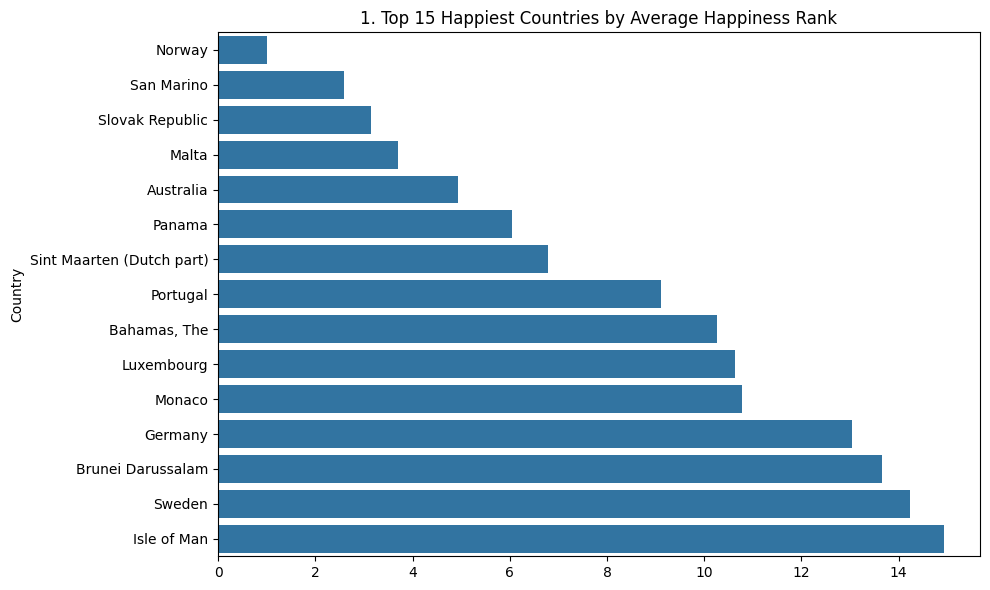

In [13]:
fig = plt.figure(figsize=(10,6))
top_happy = df.groupby('Country')['Happiness_Rank'].mean().sort_values().head(15)
sns.barplot(x=top_happy.values, y=top_happy.index)
plt.title(f'{plot_no}. Top 15 Happiest Countries by Average Happiness Rank')
show_fig()
plot_no += 1

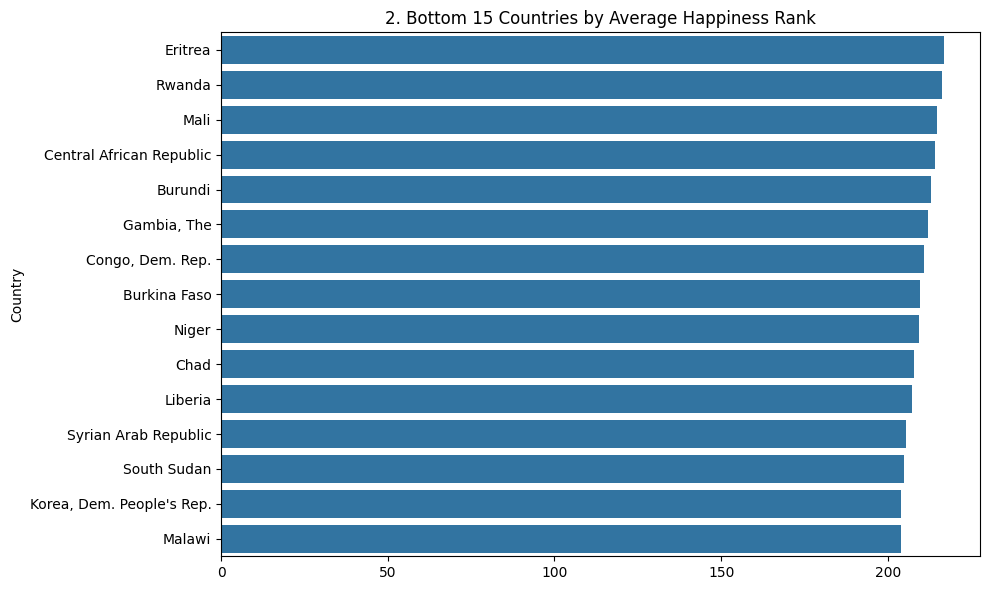

In [14]:
fig = plt.figure(figsize=(10,6))
worst_happy = df.groupby('Country')['Happiness_Rank'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=worst_happy.values, y=worst_happy.index)
plt.title(f'{plot_no}. Bottom 15 Countries by Average Happiness Rank')
show_fig()
plot_no += 1

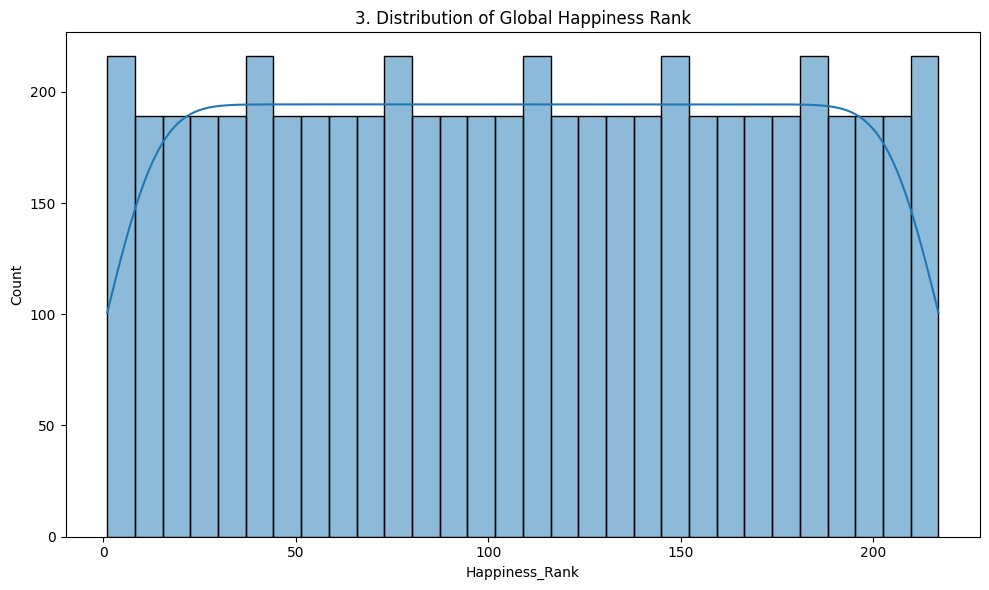

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Happiness_Rank'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Global Happiness Rank')
show_fig()
plot_no += 1

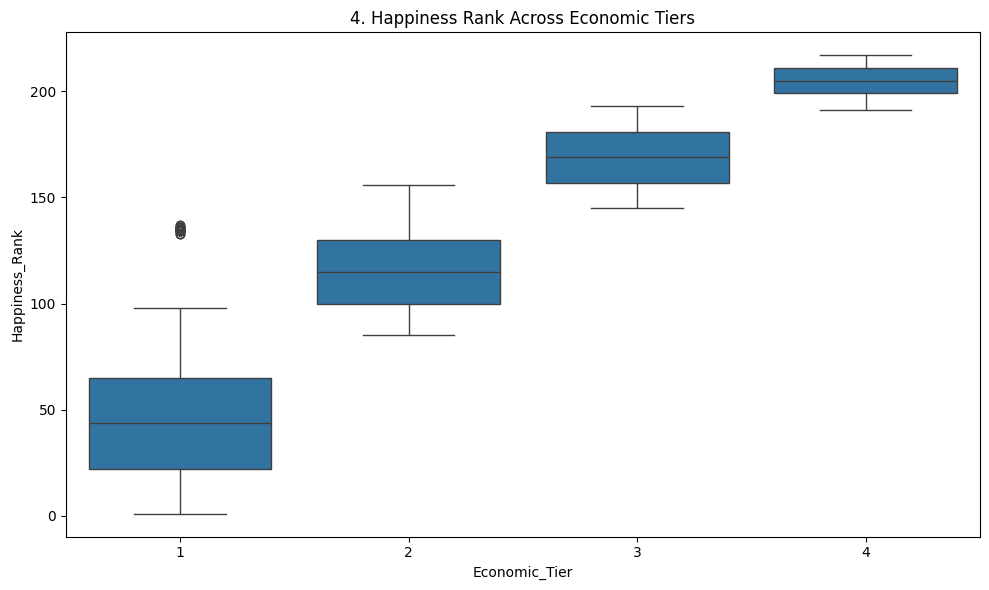

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Economic_Tier', y='Happiness_Rank')
plt.title(f'{plot_no}. Happiness Rank Across Economic Tiers')
show_fig()
plot_no += 1

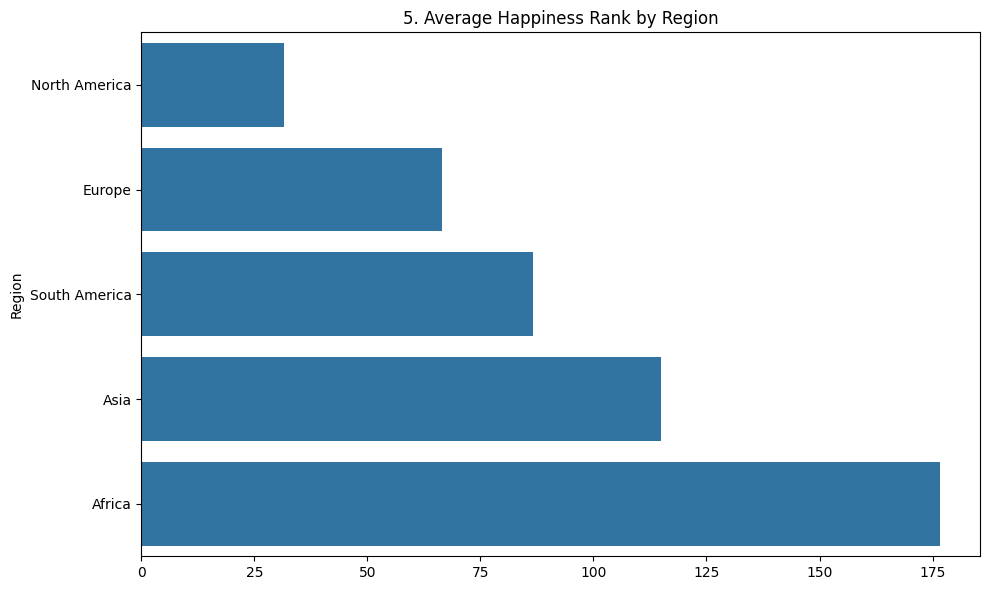

In [17]:
fig = plt.figure(figsize=(10,6))
region_happy = df.groupby('Region')['Happiness_Rank'].mean().sort_values()
sns.barplot(x=region_happy.values, y=region_happy.index)
plt.title(f'{plot_no}. Average Happiness Rank by Region')
show_fig()
plot_no += 1

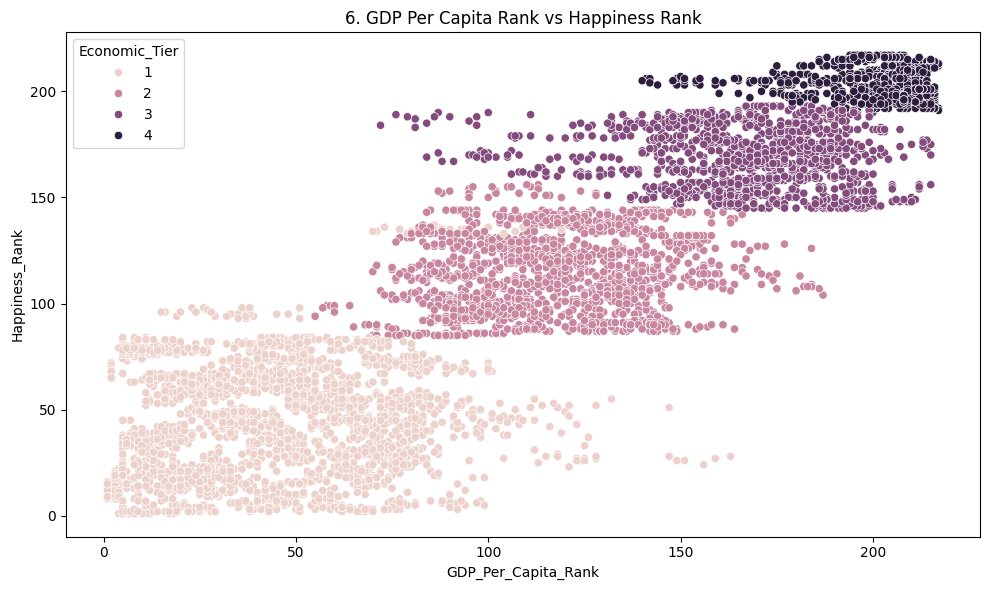

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='GDP_Per_Capita_Rank', y='Happiness_Rank', hue='Economic_Tier')
plt.title(f'{plot_no}. GDP Per Capita Rank vs Happiness Rank')
show_fig()
plot_no += 1

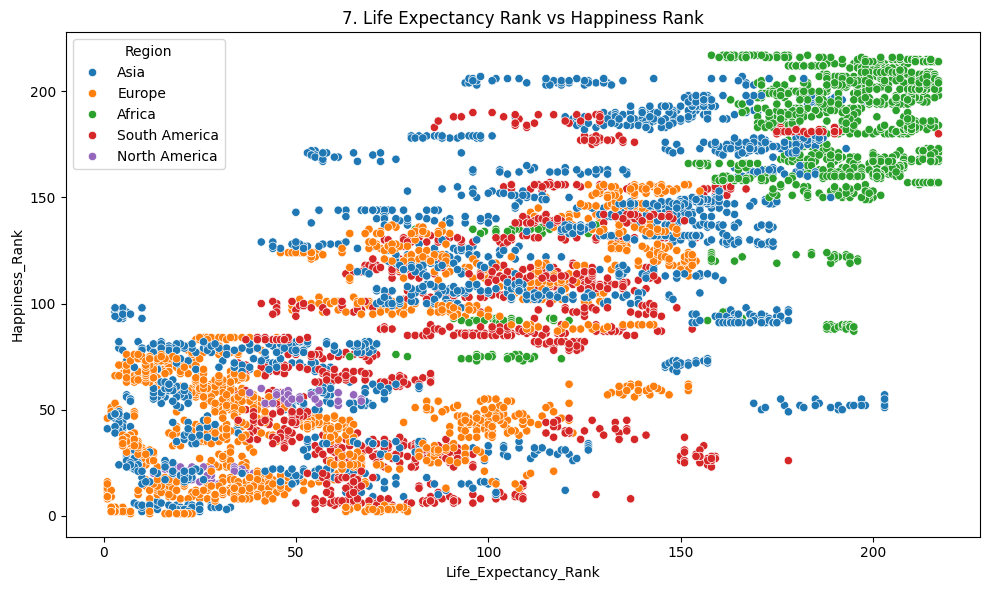

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Life_Expectancy_Rank', y='Happiness_Rank', hue='Region')
plt.title(f'{plot_no}. Life Expectancy Rank vs Happiness Rank')
show_fig()
plot_no += 1

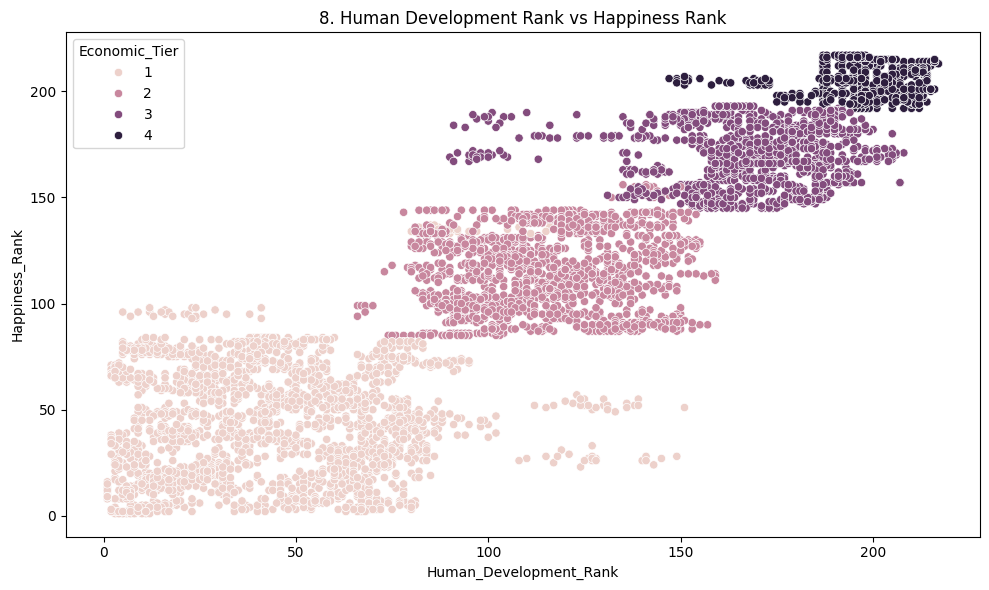

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Human_Development_Rank', y='Happiness_Rank', hue='Economic_Tier')
plt.title(f'{plot_no}. Human Development Rank vs Happiness Rank')
show_fig()
plot_no += 1

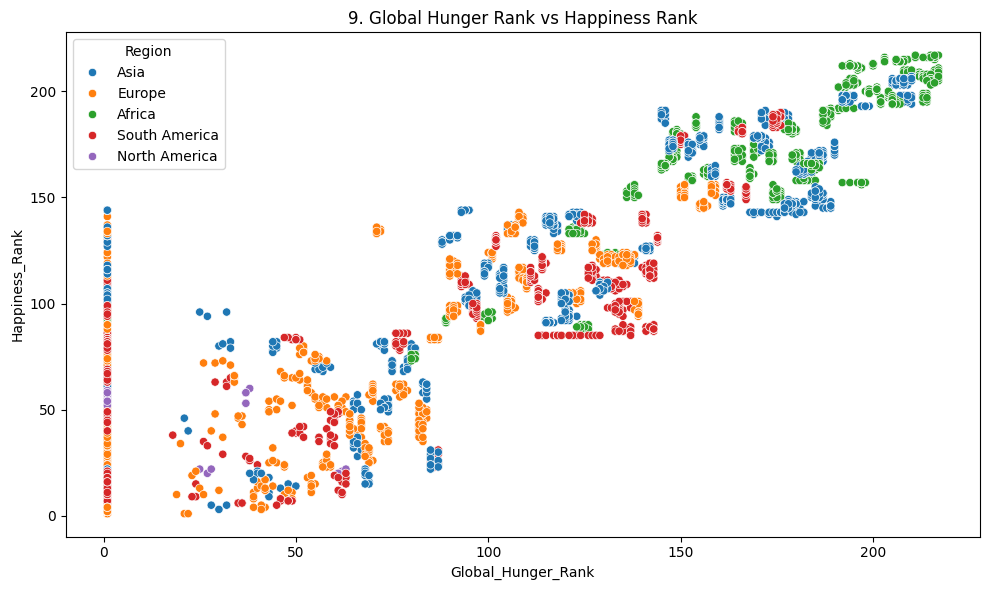

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Global_Hunger_Rank', y='Happiness_Rank', hue='Region')
plt.title(f'{plot_no}. Global Hunger Rank vs Happiness Rank')
show_fig()
plot_no += 1

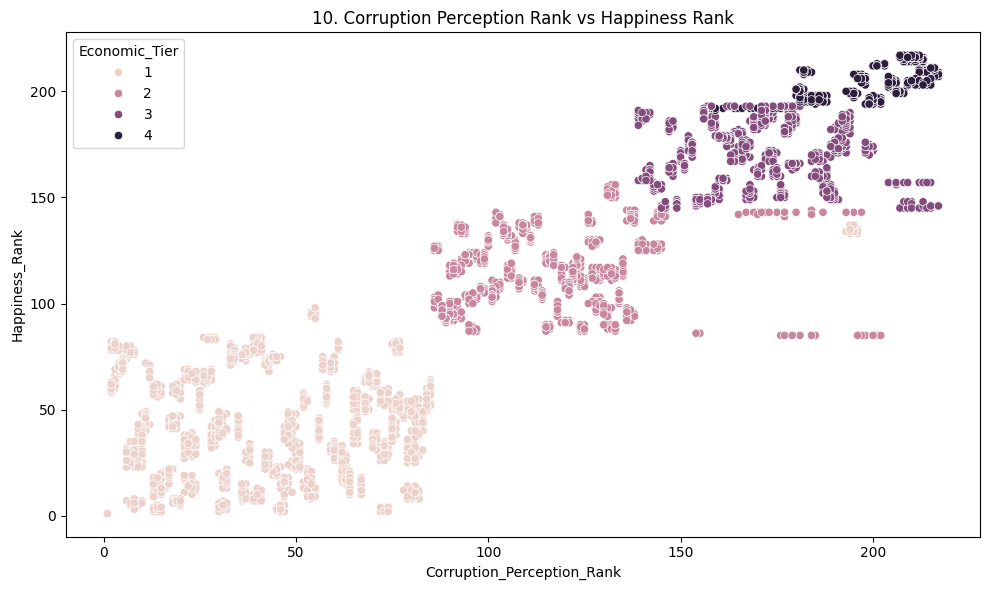

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Corruption_Perception_Rank', y='Happiness_Rank', hue='Economic_Tier')
plt.title(f'{plot_no}. Corruption Perception Rank vs Happiness Rank')
show_fig()
plot_no += 1

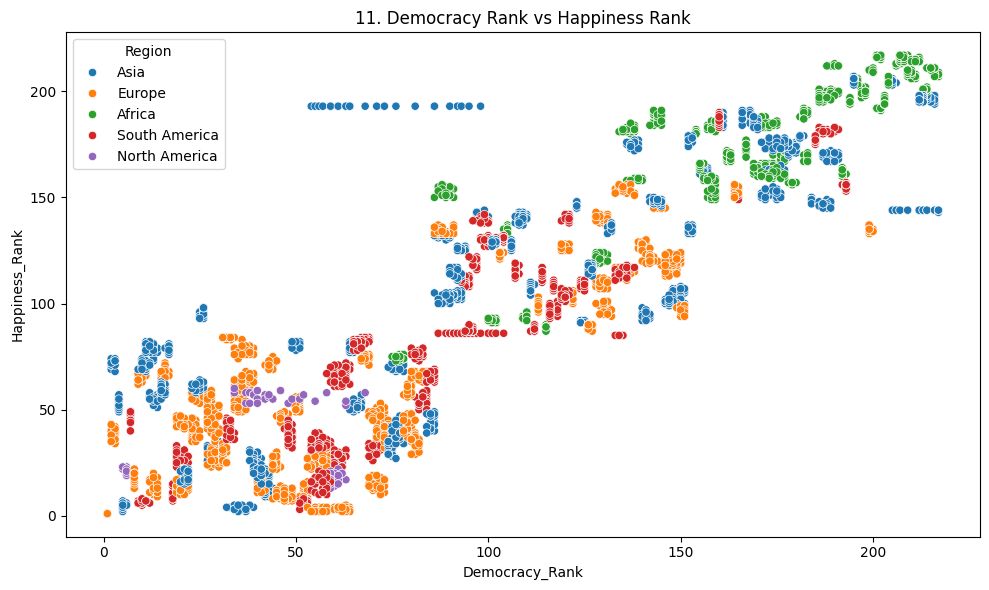

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Democracy_Rank', y='Happiness_Rank', hue='Region')
plt.title(f'{plot_no}. Democracy Rank vs Happiness Rank')
show_fig()
plot_no += 1

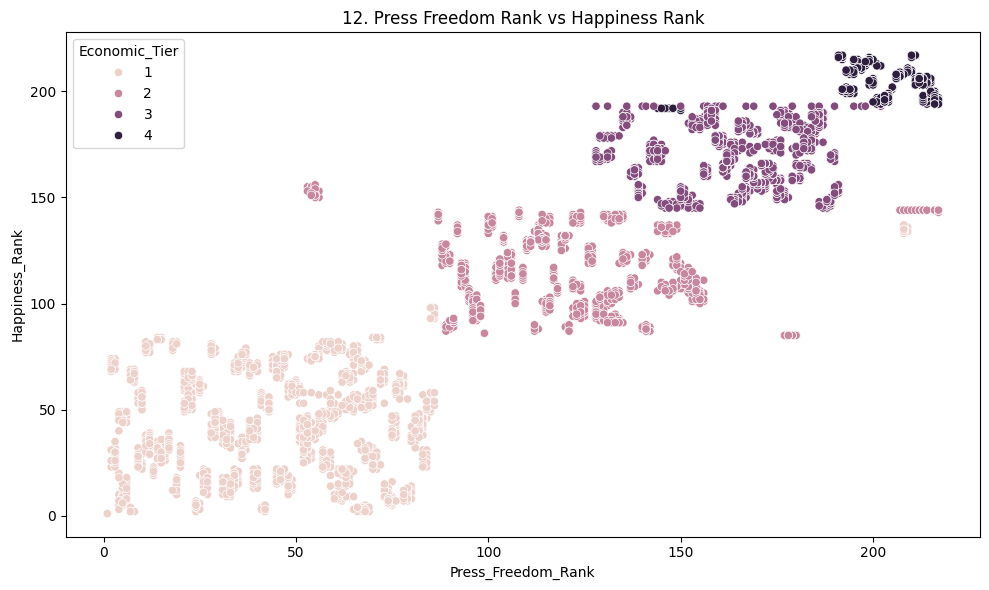

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Press_Freedom_Rank', y='Happiness_Rank', hue='Economic_Tier')
plt.title(f'{plot_no}. Press Freedom Rank vs Happiness Rank')
show_fig()
plot_no += 1

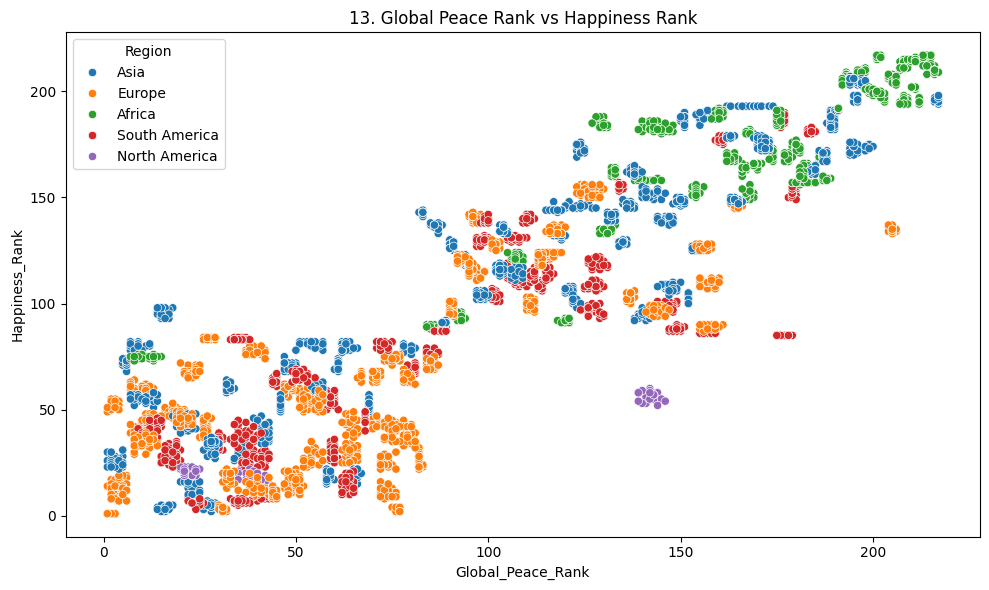

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Global_Peace_Rank', y='Happiness_Rank', hue='Region')
plt.title(f'{plot_no}. Global Peace Rank vs Happiness Rank')
show_fig()
plot_no += 1

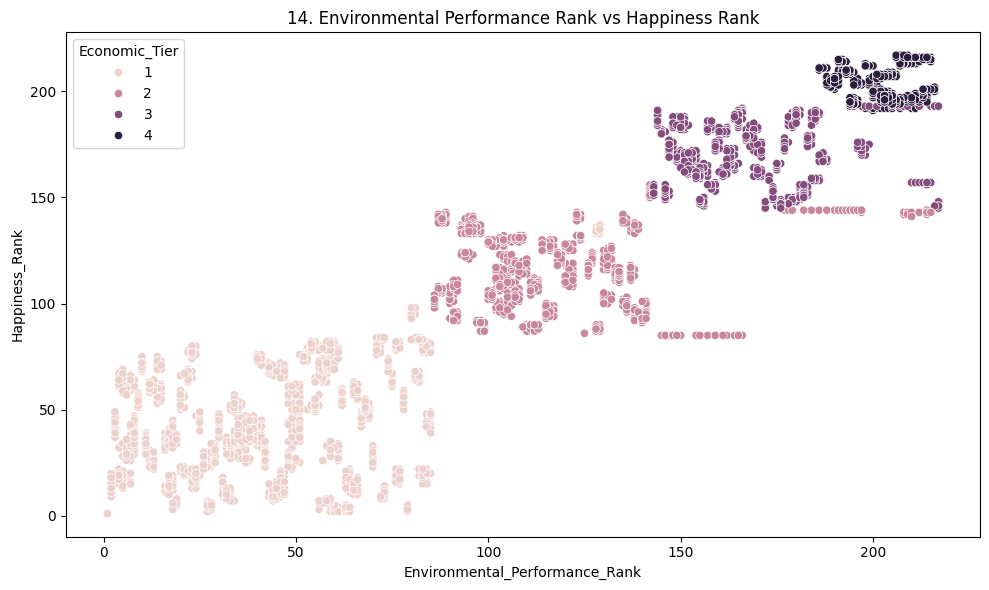

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Environmental_Performance_Rank', y='Happiness_Rank', hue='Economic_Tier')
plt.title(f'{plot_no}. Environmental Performance Rank vs Happiness Rank')
show_fig()
plot_no += 1

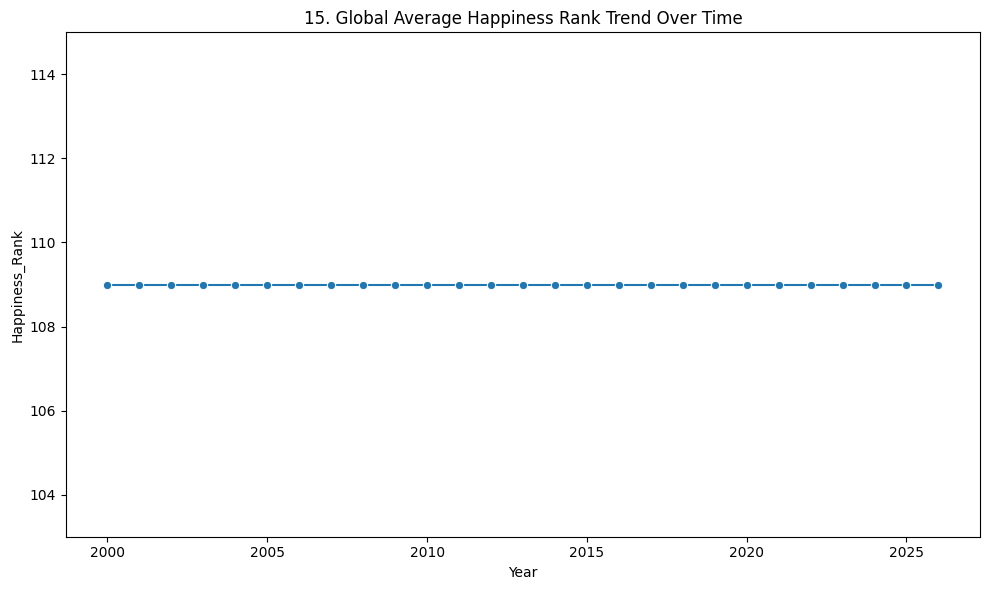

In [27]:
fig = plt.figure(figsize=(10,6))
yearly = df.groupby('Year')['Happiness_Rank'].mean().reset_index()
sns.lineplot(data=yearly, x='Year', y='Happiness_Rank', marker='o')
plt.title(f'{plot_no}. Global Average Happiness Rank Trend Over Time')
show_fig()
plot_no += 1

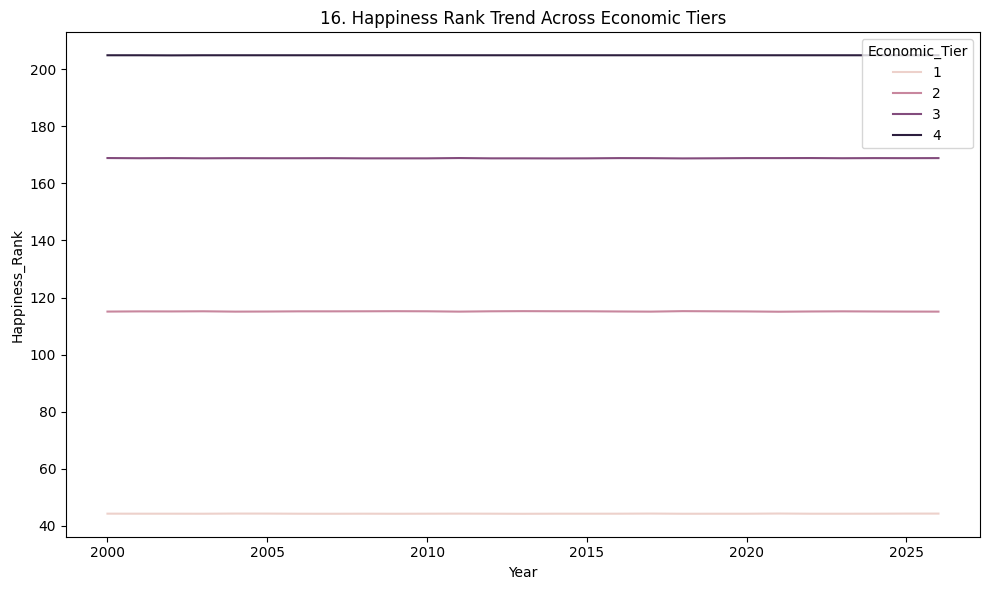

In [28]:
fig = plt.figure(figsize=(10,6))
tier_year = df.groupby(['Year','Economic_Tier'])['Happiness_Rank'].mean().reset_index()
sns.lineplot(data=tier_year, x='Year', y='Happiness_Rank', hue='Economic_Tier')
plt.title(f'{plot_no}. Happiness Rank Trend Across Economic Tiers')
show_fig()
plot_no += 1

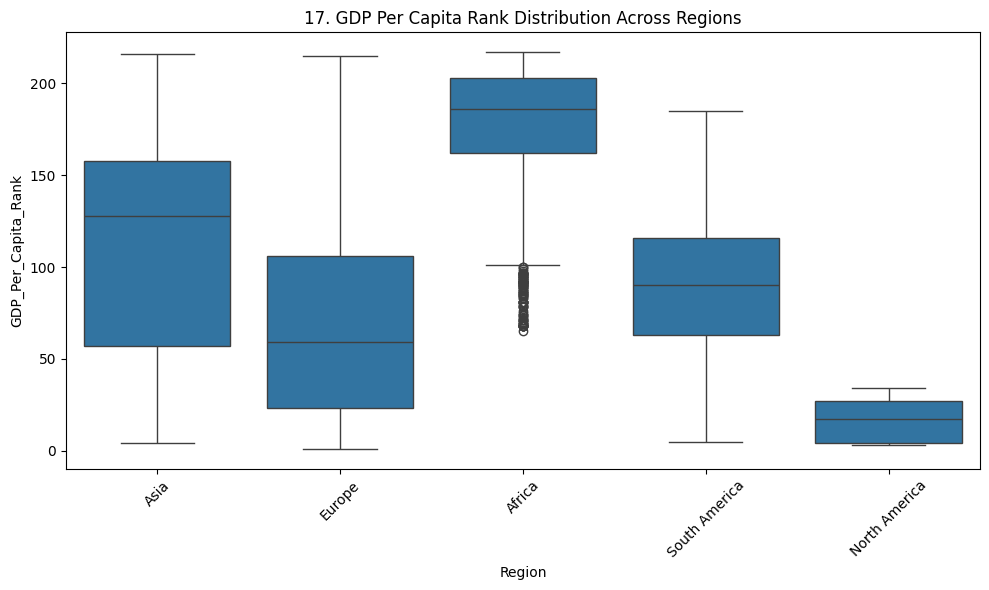

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Region', y='GDP_Per_Capita_Rank')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. GDP Per Capita Rank Distribution Across Regions')
show_fig()
plot_no += 1

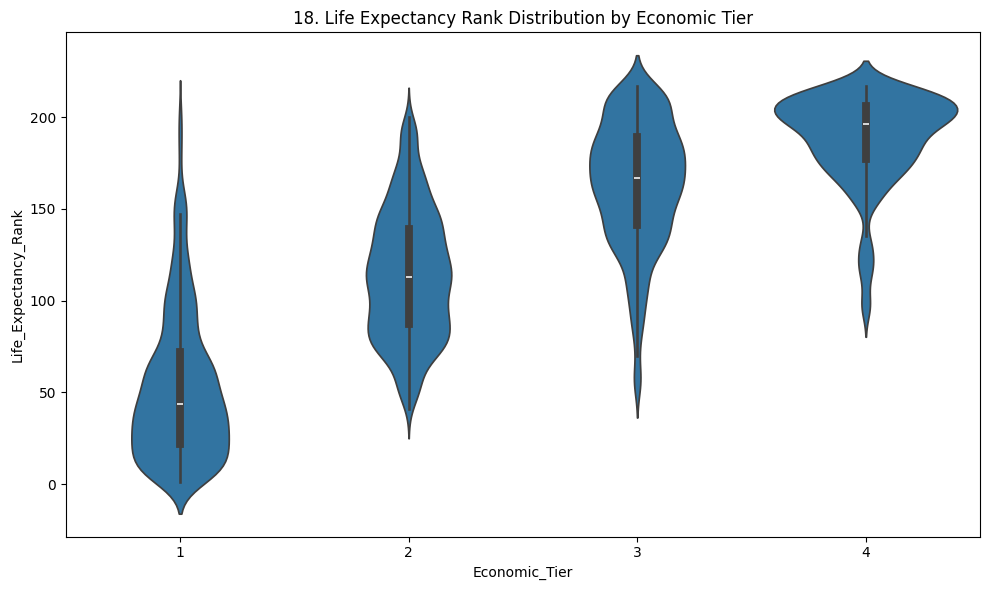

In [30]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Economic_Tier', y='Life_Expectancy_Rank')
plt.title(f'{plot_no}. Life Expectancy Rank Distribution by Economic Tier')
show_fig()
plot_no += 1

<Figure size 1000x600 with 0 Axes>

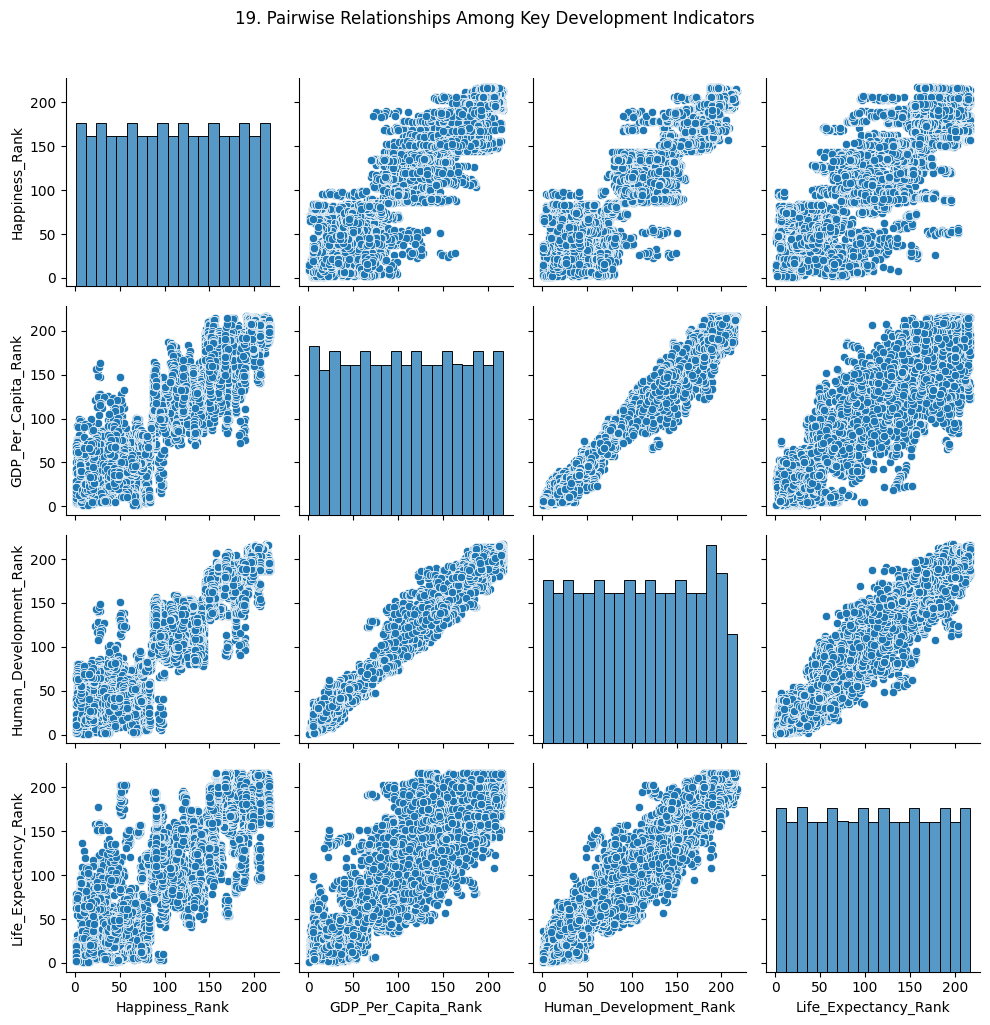

In [31]:
fig = plt.figure(figsize=(10,6))
sns.pairplot(
    df[['Happiness_Rank','GDP_Per_Capita_Rank','Human_Development_Rank','Life_Expectancy_Rank']]
)
plt.suptitle(f'{plot_no}. Pairwise Relationships Among Key Development Indicators', y=1.02)
show_fig()
plot_no += 1

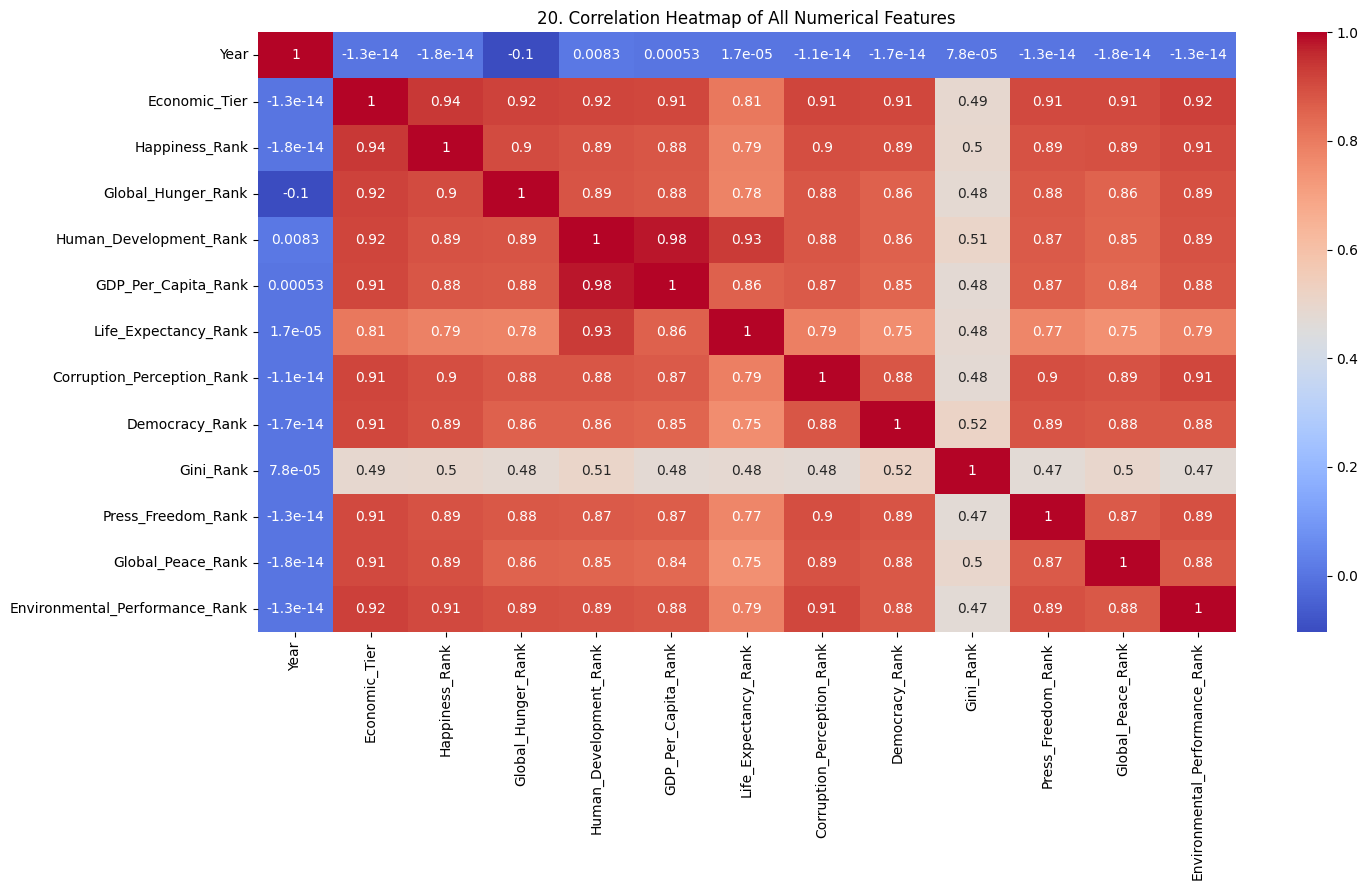

In [32]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(15, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of All Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Create a copy of the dataset

In [33]:
data = df.copy()

## Encode categorical columns

In [34]:
label_encoders = {}
for col in data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

## Define features and target

In [35]:
X = data.drop('Economic_Tier', axis=1)
y = data['Economic_Tier']

## Split the dataset

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Create SVM pipeline with feature scaling

In [37]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

## Train the model

In [38]:
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('classifier', SVC())])

## Predict on test data

In [39]:
y_pred = model.predict(X_test)

## Print model accuracy

In [40]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy*100:.2f}%")

Accuracy Score: 1.0000
Accuracy Percentage: 100.00%


## Plot confusion matrix

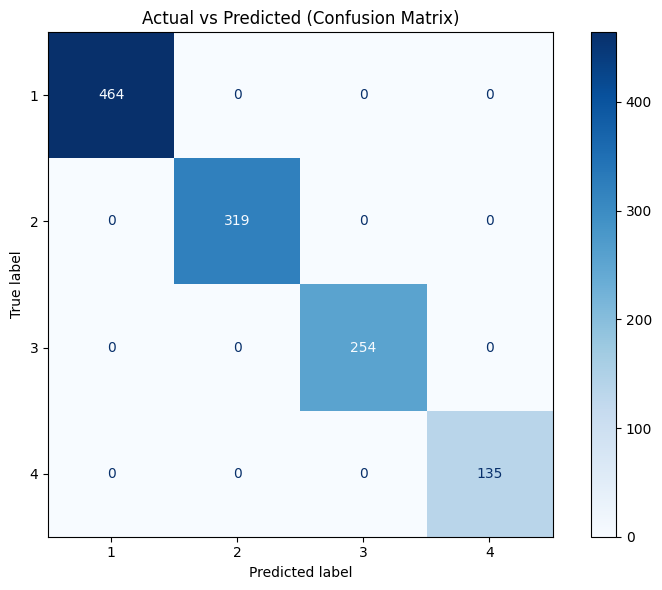

In [41]:
fig = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues',
    ax=plt.gca()
)
plt.title("Actual vs Predicted (Confusion Matrix)")
plt.tight_layout()
plt.show()